<a href="https://colab.research.google.com/github/A1Daniel1/redesNeuronales/blob/main/labNN_PTIA_c.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ESCUELA COLOMBIANA DE INGENIERÍA
# PRINCIPIOS Y TECNOLOGÍAS IA 2026-1
## REDES NEURONALES
## LABORATORIO 1/4

**NOMBRES:**
1. Daniel Alexander Ahumada León

2. Juan Manuel Neira Zuluaga

**OBJETIVOS**

Desarrollar competencias básicas para:
1. Modelar y resolver problemas usando redes neuronales
2. Implementar los algoritmos hacia adelante (FEED-FORWARD) y hacia atrás con  aprendizaje (BACKPROPAGATION)
3. Apropiar un framework para redes neuronales (*keras*)

**ENTREGABLE**


*Reglas para el envío de los entregables*:

* **Forma de envío:**
Esta tarea se debe enviar únicamente a través de la plataforma Moodle en la actividad definida. Se tendrán dos entregas: inicial y final.

* **Formato de los archivos:**
***El entregable debe ser unicamente este archivo ".ipynb".*** Descargar como copia y cambiar la nomenclatura. No se permiten enlaces a colab

* **Nomenclatura para nombrar los archivos:**
El archivo deberá ser renombrado, “RN-lab-” seguido por los usuarios institucionales de los autores ordenados alfabéticamente (por ejemplo, se debe adicionar pedroperez al nombre del archivo, si el correo electrónico de Pedro Pérez es pedro.perez@mail.escuelaing.edu.co)




# PARTE I. IMPLEMENTACIÓN DE RED NEURONAL

Para este apartado se va a implementar una red neuronal con algoritmo de aprendizaje, en este caso propagación hacia atras del error.

*Introducido en la década de 1960 y popularizado casi 30 años después (1989) por Rumelhart, Hinton y Williams en el artículo titulado «Learning representations by back-propagating errors».*

## IMPLEMENTACIÓN DE RED NEURONAL CON PROPAGACIÓN HACIA ATRÁS

Implementar una red neuronal totalmente conectada desde su definición simple; calculando una salida $\check{Y} (Yp)$ para unas entradas $X$.

**Propiedades y parámetros:**

*   Tarea: **Clasificación multiple**
*   Tipo de capas: **Densas**
*   Métrica para evaluación : **ACCURACY**

<div>
<img src="https://cdn.prod.website-files.com/660ef16a9e0687d9cc27474a/662c426738658d748af1b20d_644af5900694f1102fb9b470_classification_guide_apc05.png" width="350"/>
</div>

> **Funciones de activación**

*   Función de activación en *Capas ocultas* : **ReLU**

<div>
<img src="https://intuitivetutorial.com/wp-content/uploads/2023/07/ReLU-1.png" width="350"/>
</div>

*   Función de activación en *Capa de salida* : **Sigmoide**

<div>
<img src="https://doimages.nyc3.cdn.digitaloceanspaces.com/010AI-ML/content/images/2018/06/sigm.png" width="350"/>
</div>

> **Funcion de costo**

*   Función de costo/perdida «error»: **Entropia Cruzada «Cross-Entropy»**

<div>
<img src="https://framerusercontent.com/images/jiDTkbQC7DPO2z2XmxqoeMsrkA.webp?width=1300&height=508" width="450"/>
</div>







## Paso 1. Derivadas

# Paso 1: Derivación de funciones de activación y de costo

En esta sección se presentan las derivadas matemáticas necesarias para la implementación del algoritmo de retropropagación (backpropagation).

## 1. Derivada de la función Sigmoide
La función sigmoide se define como:
$$\sigma(x) = \frac{1}{1 + e^{-x}}$$

Para obtener su derivada $\sigma'(x)$:
1. Reescribimos la función como una potencia: $\sigma(x) = (1 + e^{-x})^{-1}$.
2. Aplicamos la regla de la cadena: 
   $$\sigma'(x) = -1(1 + e^{-x})^{-2} \cdot (e^{-x} \cdot -1) = \frac{e^{-x}}{(1 + e^{-x})^2}$$
3. Expresamos en términos de $\sigma(x)$:
   $$\sigma'(x) = \frac{1}{1 + e^{-x}} \cdot \frac{e^{-x}}{1 + e^{-x}} = \sigma(x) \cdot (1 - \sigma(x))$$

**Resultado:** $\sigma'(x) = \sigma(x)(1 - \sigma(x))$

---

## 2. Derivada de la función ReLU
La función ReLU (Rectified Linear Unit) es:
$$f(x) = \max(0, x) = \begin{cases} x & \text{si } x > 0 \\ 0 & \text{si } x \leq 0 \end{cases}$$

Su derivada se define por tramos:
1. Para $x > 0$, la pendiente es constante: $f'(x) = 1$.
2. Para $x \leq 0$, la función es constante: $f'(x) = 0$.

**Resultado:**
$$f'(x) = \begin{cases} 1 & \text{si } x > 0 \\ 0 & \text{si } x \leq 0 \end{cases}$$

---

## 3. Derivada de la función de costo: Entropía Cruzada
Para clasificación binaria, la función de costo es:
$$L(y, \hat{y}) = - [y \log(\hat{y}) + (1 - y) \log(1 - \hat{y})]$$

Derivando respecto a la predicción $\hat{y}$:
1. Aplicamos la derivada del logaritmo:
   $$\frac{\partial L}{\partial \hat{y}} = - \left[ \frac{y}{\hat{y}} - \frac{1 - y}{1 - \hat{y}} \right]$$
2. Simplificamos la fracción:
   $$\frac{\partial L}{\partial \hat{y}} = \frac{\hat{y} - y}{\hat{y}(1 - \hat{y})}$$

**Nota para la implementación:** Si combinamos esta derivada con la de la función sigmoide en la última capa ($\hat{y} = \sigma(z)$), el gradiente respecto a la entrada neta $z$ se simplifica a:
$$\frac{\partial L}{\partial z} = \hat{y} - y$$

## Paso 2. Implementación del código para ANN (Dense)

### LIBRERÍA NECESARIA

In [6]:
import numpy as np
from abc import ABC, abstractmethod

### FUNCIONES DE BASE: MÉTRICA, COSTO Y ACTIVACIÓN

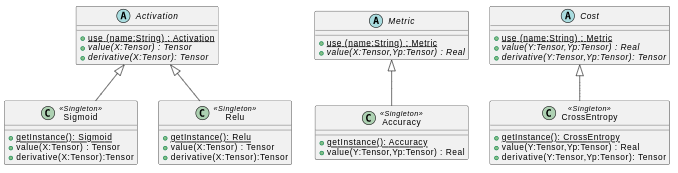

### MÉTRICA

In [8]:
class Metric(ABC):
  """ Abstracta: define entradas, salidas y el comportamiento inicial de los métodos clave para cualquier metrica
  Representa la metrica de una red neuronal
  """
  def use(self, name: str):
    """ obtiene metrica (OBJ) a partir del nombre
    Args:
      name (str): nombre esperado de la metrica
    Returns:
      self (Metric): objeto metrica
    """
    pass

  def value(self, Y: np.ndarray, Yp:np.ndarray):
    """ computa el desempeño (accuracy) de la red (> 0.6 es 1)
    Args:
      Y (ndarray): valores de salidas esperadas (etiquetadas)
      Yp (ndarray): valores de salidas obtenidas
    Return:
      A (float): valor del desempeño
    """
    pass

In [9]:
# Documentar los métodos implementados
class Accuracy(Metric):
  """ Metrica de exactitud (acertados / totales). Implementa Metric
  """
  def Acurracy(self):
    pass

  def value(self, Y: np.ndarray, Yp: np.ndarray) -> np.ndarray:
    predicciones_booleanas = Yp > 0.6
    Y_predichas = predicciones_booleanas.astype(int)
    
    aciertos = (Y_predichas == Y)

    desempeño = np.mean(aciertos)
    return desempeño

In [10]:
# Adicione los casos de prueba de los métodos implementados

# Datos de ejemplo
Y_real = np.array([1, 0, 1, 1, 0])
Y_pred = np.array([0.9, 0.2, 0.58, 0.62, 0.4])

metrica = Accuracy()

resultado = metrica.value(Y_real, Y_pred)

print(f"El Accuracy calculado es: {resultado}")

El Accuracy calculado es: 0.8


### COSTO

In [11]:
class Cost(ABC):
  """ Abstracta: define entradas, salidas y el comportamiento inicial de los métodos clave para cualquier función de costo
  Representa la función de costo o error de una red neuronal
  """
  def use(self, name: str):
    """ obtiene función de costo (OBJ) a partir del nombre
    Args:
      name (str): nombre esperado de la función
    Returns:
      self (Cost): objeto función de costo
    """
    pass

  def value(self, Y: np.ndarray, Yp: np.ndarray) -> float:
    """ computa la función de costo
    Args:
      Y (ndarray): valores de salida obtenidos
      Yp (ndarray): valores de salida esperados
    Returns:
      S (float): valor de computo de la función de costo
    """
    pass

  def derivative(self, Y: np.ndarray, Yp: np.ndarray) -> np.ndarray:
    """ computa la derivada de la función de costo (gradiente) <elemento por elemento>
    Args:
      Y (ndarray): valores de salida obtenidos
      Yp (ndarray): valores de salida esperados
    Returns:
      ∇E(X) (ndarray): valores para la derivada de función de costo
    """
    pass

In [12]:
# Documentar los métodos implementados
class CrossEntropy(Cost):
  """ Función de costo Entropia Cruzada. Implementa Cost
  """
  def CrossEntropy(self):
    pass

  def value(self, Y: np.ndarray, Yp: np.ndarray) -> np.ndarray:
    """
      Calcula el error global de la red.
      Fórmula: -mean(Y * log(Yp) + (1-Y) * log(1-Yp))
    """
    epsilon = 1e-15
    Yp = np.clip(Yp, epsilon, 1 - epsilon)
    
    loss = -np.mean(Y - np.log(Yp) + (1 - Y) * np.log(1 - Yp))
    
    return loss

  def derivative(self, Y: np.ndarray, Yp: np.ndarray) -> np.ndarray:
    epsilon = 1e-15
    Yp = np.clip(Yp, epsilon, 1 - epsilon)

    return ((Yp - Y) / (Yp * (1 - Yp)))


In [13]:
# Adicione los casos de prueba de los métodos implementados

# Datos de ejemplo
Y_true = np.array([1, 0])
Y_pred = np.array([0.9, 0.1]) 

ce = CrossEntropy()
error = ce.value(Y_true, Y_pred)
gradiente = ce.derivative(Y_true, Y_pred)

print(f"Error (debe ser bajo): {error:.4f}")
print(f"Gradiente: {gradiente}")



Error (debe ser bajo): -1.6513
Gradiente: [-1.11111111  1.11111111]


### ACTIVACION

In [14]:
class Activation(ABC):
  """ Abstracta: define entradas, salidas y el comportamiento inicial de los métodos clave de cualquier función de activación
  Representa la función de activación de cualquier neurona en la red neuronal
  """
  def use(self, name: str):
    """ obtiene función de activación (OBJ) a partir del nombre
    Args:
      name (str): nombre esperado de la función
    Returns:
      self (Activation): objeto función de activación
    """
    pass

  def value(self, X: np.ndarray) -> np.ndarray:
    """ computa la función de activación <elemento por elemento>
    Args:
      X (ndarray): valores de entrada
    Returns:
      S (ndarray): valores de computo de la función de activación
    """
    pass

  def derivative(self, X: np.ndarray) -> np.ndarray:
    """ computa la derivada de la función de activación (gradiente) <elemento por elemento>
    Args:
      X (ndarray): valores de entrada
    Returns:
      ∇E(X) (ndarray): valores para la derivada de función de activación
    """
    pass

In [15]:
# Documentar los métodos implementados
class Sigmoid(Activation):
  """ Función de activación sigmoide. Implementa Activación
  """
  def Sigmoid(self):
    pass

  def value(self, X: np.ndarray) -> np.ndarray:
    return 1 / (1 + np.exp(-np.clip(X, -500, 500)))

  def derivative(self, X: np.ndarray) -> np.ndarray:
    s = self.value(X)
    return s * (1 - s)

In [16]:
# Documentar los métodos implementados
class Relu(Activation):
  """ Función de activación RELU. Implementa Activación
  """
  def Relu(self):
    pass

  def value(self, X: np.ndarray) -> np.ndarray:
    return np.maximum(0, X)

  def derivative(self, X: np.ndarray) -> np.ndarray:
    return (X > 0).astype(float)

In [17]:
# Adicione los casos de prueba de los métodos implementados

sig = Sigmoid()
test_val = np.array([0])
print(f"Valor en 0: {sig.value(test_val)}")       
print(f"Derivada en 0: {sig.derivative(test_val)}") 

print("-"*50)

relu_layer = Relu()
test_data = np.array([-5, 0, 5])

print(f"Entrada: {test_data}")
print(f"Salida (value): {relu_layer.value(test_data)}")       

print(f"Derivada (derivative): {relu_layer.derivative(test_data)}") 


Valor en 0: [0.5]
Derivada en 0: [0.25]
--------------------------------------------------
Entrada: [-5  0  5]
Salida (value): [0 0 5]
Derivada (derivative): [0. 0. 1.]


## RED NEURONAL TOTALMENTE CONECTADA «DENSE»


#### Nomenclatura

* **Datos**
  - *c*: número de características
  - *m*: número de ejemplares
  - **x**, **X** : entradas. Un ejemplo (c) o todos los ejemplos (cxm)
  - **y**, **Y** : salidas reales. Un ejemplo (cx1) o todos los ejemplos(cxm)
  - **yp**, **Yp** : salidas estimadas. Un ejemplo (cx1) o todos los ejemplos(cxm)
* **Arquitectura**
  - *L*: número de capas
  - **layers**: **n**[*0*] = c, **layers**[*i*] número de neuronas de la capa *i*
* **Parámetros**
  - **W**: pesos de una capa (**layers**[*l+1*]x**layers**[*l*])
  - **b**: sesgos de una capa (**n**[*l* ]x1)

* **Gradientes**
  - **dW**: gradiente de **W**
  - **db**: gradiente de **b**

*Incluya en este apartado el proceso de la derivación de los gradientes*

---
**Gradiente dW**

Se define $\delta^{[l]} = \frac{\partial L}{\partial Z^{[l]}}$ como el **error local** de la capa $l$.

Para la **capa de salida** ($l=L$), combinando BCE + Sigmoide:
$$\delta^{[L]} = \hat{Y} - Y$$

Para **capas ocultas** con ReLU:
$$\delta^{[l]} = \left(W^{[l+1]}\right)^\top \cdot \delta^{[l+1]} \odot \text{ReLU}'(Z^{[l]})$$

El gradiente de los pesos es:
$$\frac{\partial L}{\partial W^{[l]}} = \frac{1}{m}\, \delta^{[l]} \cdot \left(A^{[l-1]}\right)^\top$$

donde $m$ es el número de ejemplos.

---
**Gradiente db**

El gradiente de los sesgos es la media de los errores locales sobre todos los ejemplos:
$$\frac{\partial L}{\partial b^{[l]}} = \frac{1}{m} \sum_{i=1}^{m} \delta^{[l]}_i$$


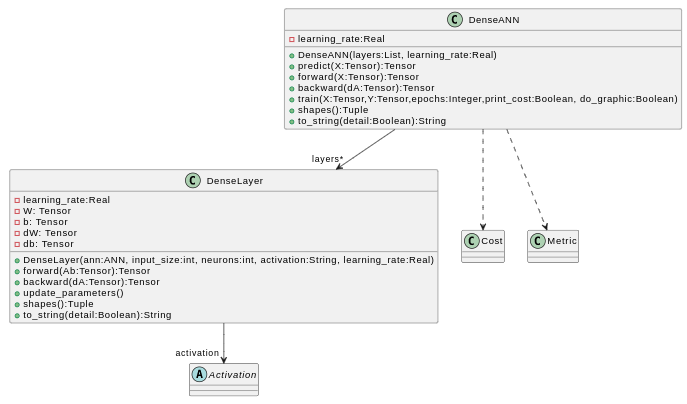

In [20]:
import matplotlib.pyplot as plt

class DenseANN:
    """Red neuronal totalmente conectada (Dense ANN).
    Capas ocultas con ReLU, capa de salida con Sigmoide.
    Optimización con gradiente descendente estocástico.
    """

    def __init__(self, layers: list, learning_rate: float):
        """Inicializa la red.
        Args:
          layers (list): [n_entradas, n_oculta1, ..., n_salida]
          learning_rate (float): tasa de aprendizaje η
        """
        self.learning_rate = learning_rate
        self.layers_config = layers
        self.network_layers = []
        self.cost_function = CrossEntropy()
        self.metric = Accuracy()

        # Construir capas: ocultas → ReLU, salida → Sigmoid
        for i in range(1, len(layers)):
            activation = 'relu' if i < len(layers) - 1 else 'sigmoid'
            self.network_layers.append(
                DenseLayer(layers[i-1], layers[i], activation, learning_rate)
            )

    # ── Predicción (umbral 0.5) ──────────────────────────────────────────
    def predict(self, X: np.ndarray):
        """Retorna etiquetas binarias (0/1).
        Args:
          X (ndarray): entradas de forma (n_features, m)
        Return:
          Yp (ndarray): predicciones binarias (1, m)
        """
        return (self.forward(X) > 0.5).astype(int)

    # ── Propagación hacia adelante ───────────────────────────────────────
    def forward(self, X: np.ndarray):
        """Pasa X por todas las capas y devuelve Ŷ.
        Args:
          X (ndarray): entradas de forma (n_features, m)
        Return:
          A (ndarray): salidas de forma (n_salida, m)
        """
        A = X
        for layer in self.network_layers:
            A = layer.forward(A)
        return A

    # ── Propagación hacia atrás ─────────────────────────────────────────
    def backward(self, dA: np.ndarray):
        """Propaga los gradientes de salida hacia la entrada.
        Args:
          dA (ndarray): ∂L/∂A de la capa de salida, forma (n_salida, m)
        """
        for layer in reversed(self.network_layers):
            dA = layer.backward(dA)

    # ── Entrenamiento ───────────────────────────────────────────────────
    def train(self, X: np.ndarray, Y: np.ndarray, epochs: int,
              print_cost: bool = True, do_graphic: bool = True):
        """Entrena la red con gradiente descendente por lotes completos.
        Args:
          X (ndarray): entradas (n_features, m)
          Y (ndarray): etiquetas (1, m)
          epochs (int): número de épocas
          print_cost (bool): imprimir costo cada 100 épocas
          do_graphic (bool): graficar curva de costo
        Return:
          costs (list): historia de costos
        """
        costs = []
        for epoch in range(epochs):
            Yp   = self.forward(X)                       # propagación adelante
            cost = self.cost_function.value(Y, Yp)       # costo
            dA   = self.cost_function.derivative(Y, Yp)  # ∂L/∂Ŷ
            self.backward(dA)                            # propagación atrás
            for layer in self.network_layers:            # actualizar parámetros
                layer.update_parameters()
            costs.append(cost)
            if print_cost and epoch % 100 == 0:
                acc = self.metric.value(Y, Yp)
                print(f"Época {epoch:5d} | Costo: {cost:.4f} | Accuracy: {acc:.4f}")

        if do_graphic:
            plt.figure(figsize=(9, 4))
            plt.plot(costs, color='steelblue')
            plt.xlabel('Época'); plt.ylabel('Costo (BCE)')
            plt.title('Curva de entrenamiento'); plt.grid(True)
            plt.tight_layout(); plt.show()
        return costs

    # ── Utilidades ──────────────────────────────────────────────────────
    def shapes(self):
        """Retorna las formas (W, b) de cada capa."""
        return tuple(layer.shapes() for layer in self.network_layers)

    def to_string(self):
        lines = ["DenseANN:"]
        for i, layer in enumerate(self.network_layers):
            lines.append(f"  Capa {i+1}: {layer.to_string(detail=False)}")
        return "\n".join(lines)


## CAPA CON PERCEPTRONES

In [21]:
class DenseLayer:
    """Capa densa (fully connected) de la red neuronal."""

    def __init__(self, input_size: int, neurons: int,
                 activation: str, learning_rate: float):
        """Inicializa pesos con He (ReLU) o Xavier (Sigmoid).
        Args:
          input_size (int): neuronas / características de la capa anterior
          neurons (int): neuronas en esta capa
          activation (str): 'relu' o 'sigmoid'
          learning_rate (float): η
        """
        self.learning_rate   = learning_rate
        self.activation_name = activation

        # Inicialización de pesos
        scale = np.sqrt(2.0 / input_size) if activation == 'relu' \
                else np.sqrt(1.0 / input_size)
        self.W  = np.random.randn(neurons, input_size) * scale  # (neurons, input)
        self.b  = np.zeros((neurons, 1))                         # (neurons, 1)
        self.dW = np.zeros_like(self.W)
        self.db = np.zeros_like(self.b)

        # Función de activación
        self.activation = Relu() if activation == 'relu' else Sigmoid()

        # Cache para backprop
        self.Z      = None  # entrada lineal
        self.A      = None  # salida activada
        self.A_prev = None  # activaciones capa anterior

    # ── Propagación adelante ─────────────────────────────────────────────
    def forward(self, Ab: np.ndarray):
        """Z = W·Ab + b  → A = activation(Z).
        Args:
          Ab (ndarray): activaciones entrada, forma (input_size, m)
        Return:
          A (ndarray): activaciones salida, forma (neurons, m)
        """
        self.A_prev = Ab
        self.Z = np.dot(self.W, Ab) + self.b   # (neurons, m)
        self.A = self.activation.value(self.Z) # (neurons, m)
        return self.A

    # ── Propagación atrás ────────────────────────────────────────────────
    def backward(self, dA: np.ndarray):
        """Calcula gradientes y retorna el delta hacia la capa anterior.
        Fórmulas (m = nº ejemplos):
          δ   = dA ⊙ activation'(Z)               ← error local
          dW  = (1/m) · δ · A_prev^T
          db  = (1/m) · Σ δ
          dA_prev = W^T · δ
        Args:
          dA (ndarray): ∂L/∂A de esta capa, forma (neurons, m)
        Return:
          dA_prev (ndarray): ∂L/∂A de la capa anterior, forma (input_size, m)
        """
        m  = self.A_prev.shape[1]
        dZ = dA * self.activation.derivative(self.Z)          # δ (neurons, m)
        self.dW  = (1 / m) * np.dot(dZ, self.A_prev.T)        # (neurons, input)
        self.db  = (1 / m) * np.sum(dZ, axis=1, keepdims=True) # (neurons, 1)
        dA_prev  = np.dot(self.W.T, dZ)                        # (input, m)
        return dA_prev

    # ── Actualización de parámetros ──────────────────────────────────────
    def update_parameters(self):
        """Gradiente descendente: W -= η·dW  ;  b -= η·db."""
        self.W -= self.learning_rate * self.dW
        self.b -= self.learning_rate * self.db

    # ── Utilidades ───────────────────────────────────────────────────────
    def shapes(self):
        """Retorna formas (W.shape, b.shape)."""
        return (self.W.shape, self.b.shape)

    def to_string(self, detail: bool = False):
        s = (f"DenseLayer [{self.W.shape[1]}→{self.W.shape[0]}] "
             f"act={self.activation_name}")
        if detail:
            s += f"\n  W={self.W}\n  b={self.b}"
        return s


Época     0 | Costo: -0.3302 | Accuracy: 0.7500
Época   100 | Costo: -1.8306 | Accuracy: 1.0000
Época   200 | Costo: -2.3825 | Accuracy: 1.0000
Época   300 | Costo: -2.7771 | Accuracy: 1.0000
Época   400 | Costo: -3.0836 | Accuracy: 1.0000
Época   500 | Costo: -3.3338 | Accuracy: 1.0000
Época   600 | Costo: -3.5446 | Accuracy: 1.0000
Época   700 | Costo: -3.7267 | Accuracy: 1.0000
Época   800 | Costo: -3.8868 | Accuracy: 1.0000
Época   900 | Costo: -4.0295 | Accuracy: 1.0000
Época  1000 | Costo: -4.1582 | Accuracy: 1.0000
Época  1100 | Costo: -4.2753 | Accuracy: 1.0000
Época  1200 | Costo: -4.3828 | Accuracy: 1.0000
Época  1300 | Costo: -4.4820 | Accuracy: 1.0000
Época  1400 | Costo: -4.5741 | Accuracy: 1.0000
Época  1500 | Costo: -4.6601 | Accuracy: 1.0000
Época  1600 | Costo: -4.7408 | Accuracy: 1.0000
Época  1700 | Costo: -4.8166 | Accuracy: 1.0000
Época  1800 | Costo: -4.8883 | Accuracy: 1.0000
Época  1900 | Costo: -4.9561 | Accuracy: 1.0000


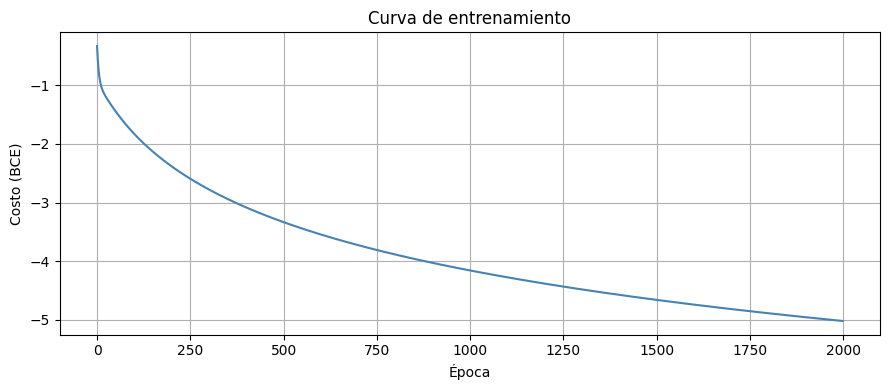


Predicciones AND:
[[0 0 0 1]]
Esperado:
[[0 0 0 1]]


In [22]:
# ─── Caso 1: Operador lógico AND ────────────────────────────────────
# AND es linealmente separable → un perceptrón debe aprender a separarlo.
np.random.seed(42)

X_and = np.array([[0,0,1,1],   # entrada 1
                   [0,1,0,1]])  # entrada 2
Y_and = np.array([[0,0,0,1]])   # salida AND

ann_and = DenseANN(layers=[2, 1], learning_rate=0.5)
ann_and.train(X_and, Y_and, epochs=2000, print_cost=True, do_graphic=True)

print("\nPredicciones AND:")
print(ann_and.predict(X_and))
print("Esperado:")
print(Y_and)

# Explicación:
# AND es linealmente separable, por lo que un único perceptrón (sin capas ocultas)
# puede aprenderlo. El costo debería bajar consistentemente hasta converger.



Época     0 | Costo: -1.2126 | Accuracy: 0.2500
Época   100 | Costo: -1.0152 | Accuracy: 1.0000
Época   200 | Costo: -1.1580 | Accuracy: 1.0000
Época   300 | Costo: -1.2500 | Accuracy: 1.0000
Época   400 | Costo: -1.3183 | Accuracy: 1.0000
Época   500 | Costo: -1.3726 | Accuracy: 1.0000
Época   600 | Costo: -1.4175 | Accuracy: 1.0000
Época   700 | Costo: -1.4559 | Accuracy: 1.0000
Época   800 | Costo: -1.4893 | Accuracy: 1.0000
Época   900 | Costo: -1.5189 | Accuracy: 1.0000
Época  1000 | Costo: -1.5454 | Accuracy: 1.0000
Época  1100 | Costo: -1.5694 | Accuracy: 1.0000
Época  1200 | Costo: -1.5914 | Accuracy: 1.0000
Época  1300 | Costo: -1.6117 | Accuracy: 1.0000
Época  1400 | Costo: -1.6304 | Accuracy: 1.0000
Época  1500 | Costo: -1.6479 | Accuracy: 1.0000
Época  1600 | Costo: -1.6643 | Accuracy: 1.0000
Época  1700 | Costo: -1.6796 | Accuracy: 1.0000
Época  1800 | Costo: -1.6941 | Accuracy: 1.0000
Época  1900 | Costo: -1.7078 | Accuracy: 1.0000


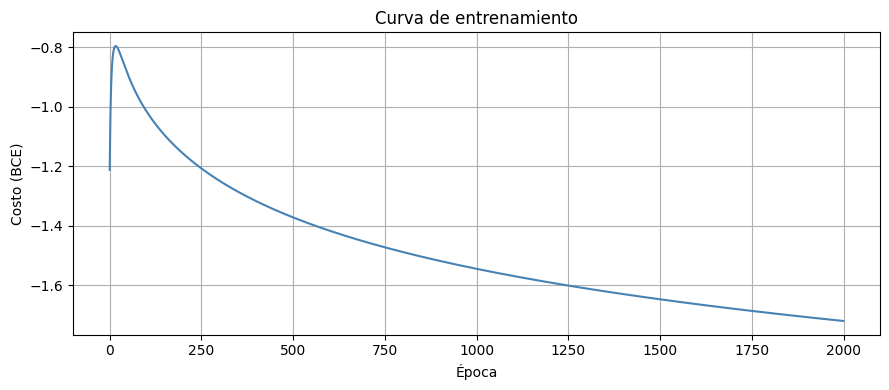


Predicciones OR:
[[0 1 1 1]]
Esperado:
[[0 1 1 1]]


In [23]:
# ─── Caso 2: Operador lógico OR ─────────────────────────────────────
# OR también es linealmente separable.
np.random.seed(42)

X_or = np.array([[0,0,1,1],
                  [0,1,0,1]])
Y_or = np.array([[0,1,1,1]])

ann_or = DenseANN(layers=[2, 1], learning_rate=0.5)
ann_or.train(X_or, Y_or, epochs=2000, print_cost=True, do_graphic=True)

print("\nPredicciones OR:")
print(ann_or.predict(X_or))
print("Esperado:")
print(Y_or)

# Explicación:
# OR es linealmente separable → el perceptrón simple converge.

Época     0 | Costo: -0.7557 | Accuracy: 0.5000
Época   100 | Costo: -0.8480 | Accuracy: 0.5000
Época   200 | Costo: -0.8468 | Accuracy: 0.5000
Época   300 | Costo: -0.8466 | Accuracy: 0.5000
Época   400 | Costo: -0.8466 | Accuracy: 0.5000
Época   500 | Costo: -0.8466 | Accuracy: 0.5000
Época   600 | Costo: -0.8466 | Accuracy: 0.5000
Época   700 | Costo: -0.8466 | Accuracy: 0.5000
Época   800 | Costo: -0.8466 | Accuracy: 0.5000
Época   900 | Costo: -0.8466 | Accuracy: 0.5000
Época  1000 | Costo: -0.8466 | Accuracy: 0.5000
Época  1100 | Costo: -0.8466 | Accuracy: 0.5000
Época  1200 | Costo: -0.8466 | Accuracy: 0.5000
Época  1300 | Costo: -0.8466 | Accuracy: 0.5000
Época  1400 | Costo: -0.8466 | Accuracy: 0.5000
Época  1500 | Costo: -0.8466 | Accuracy: 0.5000
Época  1600 | Costo: -0.8466 | Accuracy: 0.5000
Época  1700 | Costo: -0.8466 | Accuracy: 0.5000
Época  1800 | Costo: -0.8466 | Accuracy: 0.5000
Época  1900 | Costo: -0.8466 | Accuracy: 0.5000


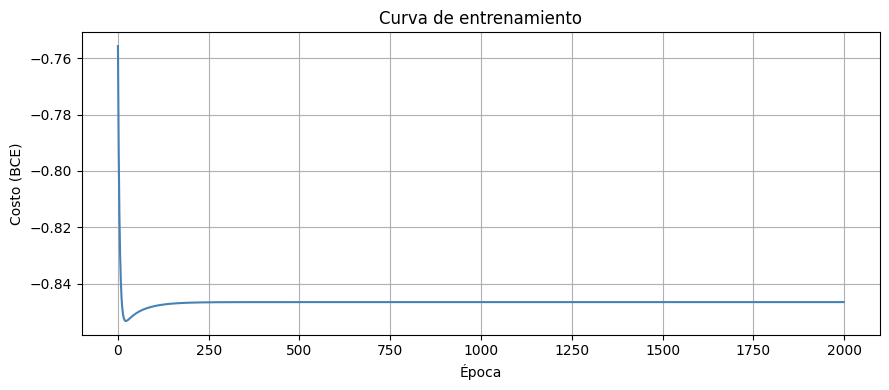


Predicciones XOR (1 capa, sin oculta):
[[0 0 0 0]]
Esperado:
[[0 1 1 0]]
Costo final: -0.8466


In [24]:
# ─── Caso 3: XOR con perceptrón simple ──────────────────────────────
# XOR NO es linealmente separable → un perceptrón simple NO puede aprenderlo.
np.random.seed(42)

X_xor = np.array([[0,0,1,1],
                   [0,1,0,1]])
Y_xor = np.array([[0,1,1,0]])

ann_xor1 = DenseANN(layers=[2, 1], learning_rate=0.5)
costs_xor1 = ann_xor1.train(X_xor, Y_xor, epochs=2000,
                             print_cost=True, do_graphic=True)

print("\nPredicciones XOR (1 capa, sin oculta):")
print(ann_xor1.predict(X_xor))
print("Esperado:")
print(Y_xor)
print(f"Costo final: {costs_xor1[-1]:.4f}")

# Explicación:
# El costo NO converge a 0 porque XOR no puede ser separado con una sola recta.
# Las predicciones serán incorrectas sin importar cuántas épocas se entrene.


Época     0 | Costo: -0.7175 | Accuracy: 0.5000
Época   100 | Costo: -2.0231 | Accuracy: 1.0000
Época   200 | Costo: -2.6211 | Accuracy: 1.0000
Época   300 | Costo: -2.8885 | Accuracy: 1.0000
Época   400 | Costo: -3.0693 | Accuracy: 1.0000
Época   500 | Costo: -3.2193 | Accuracy: 1.0000
Época   600 | Costo: -3.3319 | Accuracy: 1.0000
Época   700 | Costo: -3.4278 | Accuracy: 1.0000
Época   800 | Costo: -3.5099 | Accuracy: 1.0000
Época   900 | Costo: -3.5709 | Accuracy: 1.0000
Época  1000 | Costo: -3.6358 | Accuracy: 1.0000
Época  1100 | Costo: -3.6973 | Accuracy: 1.0000
Época  1200 | Costo: -3.7460 | Accuracy: 1.0000
Época  1300 | Costo: -3.7948 | Accuracy: 1.0000
Época  1400 | Costo: -3.8332 | Accuracy: 1.0000
Época  1500 | Costo: -3.8769 | Accuracy: 1.0000
Época  1600 | Costo: -3.9142 | Accuracy: 1.0000
Época  1700 | Costo: -3.9480 | Accuracy: 1.0000
Época  1800 | Costo: -3.9820 | Accuracy: 1.0000
Época  1900 | Costo: -4.0097 | Accuracy: 1.0000
Época  2000 | Costo: -4.0389 | Accuracy:

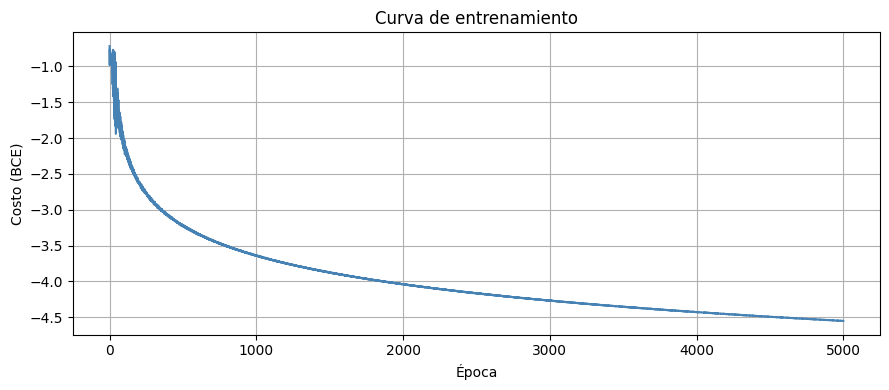


Predicciones XOR [2,2,1]:
[[0 1 1 0]]
Esperado:
[[0 1 1 0]]
Costo final: -4.5497


In [25]:
# ─── Caso 4: XOR con red multicapa [2, 2, 1] ─────────────────────────
# Una capa oculta agrega no-linealidad, permitiendo aprender XOR.
np.random.seed(0)

X_xor = np.array([[0,0,1,1],
                   [0,1,0,1]])
Y_xor = np.array([[0,1,1,0]])

ann_xor2 = DenseANN(layers=[2, 2, 1], learning_rate=1.0)
costs_xor2 = ann_xor2.train(X_xor, Y_xor, epochs=5000,
                              print_cost=True, do_graphic=True)

print("\nPredicciones XOR [2,2,1]:")
print(ann_xor2.predict(X_xor))
print("Esperado:")
print(Y_xor)
print(f"Costo final: {costs_xor2[-1]:.4f}")

# Explicación:
# Con una capa oculta de 2 neuronas y ReLU, la red aprende a combinar
# representaciones intermedias para resolver la no-linealidad del XOR.


Train: (16, 6400)  |  Test: (16, 1600)
Distribución entrenamiento → 0: 3200  1: 3200
DenseANN:
  Capa 1: DenseLayer [16→32] act=relu
  Capa 2: DenseLayer [32→16] act=relu
  Capa 3: DenseLayer [16→1] act=sigmoid
Época     0 | Costo: -0.7274 | Accuracy: 0.4005
Época   100 | Costo: -1.8712 | Accuracy: 0.7117
Época   200 | Costo: -2.2864 | Accuracy: 0.8283
Época   300 | Costo: -2.7351 | Accuracy: 0.8477
Época   400 | Costo: -3.1805 | Accuracy: 0.8586
Época   500 | Costo: -3.6038 | Accuracy: 0.8684
Época   600 | Costo: -3.9966 | Accuracy: 0.8780
Época   700 | Costo: -4.3484 | Accuracy: 0.8845
Época   800 | Costo: -4.6801 | Accuracy: 0.8908
Época   900 | Costo: -5.0001 | Accuracy: 0.8972


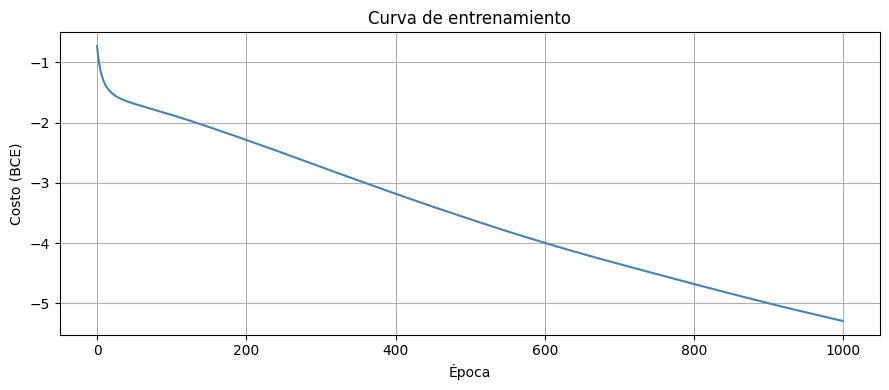


Accuracy Entrenamiento : 0.9041
Accuracy Prueba        : 0.9000


In [29]:
# ─── Caso 5: Dataset BEED_Data ───────────────────────────────────────
# El dataset tiene 4 clases (0,1,2,3). Para usar BCE+Sigmoid lo binarizamos:
#   clase 0 o 1 → 0   |   clase 2 o 3 → 1
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Cargar datos
df = pd.read_csv('BEED_Data.csv')
X_raw = df.drop('y', axis=1).values.astype(float)   # (8000, 16)
y_raw = df['y'].values                               # (8000,)
y_bin = (y_raw >= 2).astype(int)                     # binarización equilibrada

# Normalización (StandardScaler)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)               # (8000, 16)

# Split 80 / 20
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_bin, test_size=0.20, random_state=42, stratify=y_bin
)

# Transponer para (features, samples) — convención de la ANN
X_tr = X_train.T   # (16, 6400)
Y_tr = y_train.reshape(1, -1)   # (1, 6400)
X_te = X_test.T    # (16, 1600)
Y_te = y_test.reshape(1, -1)    # (1, 1600)

print(f"Train: {X_tr.shape}  |  Test: {X_te.shape}")
print(f"Distribución entrenamiento → 0: {(Y_tr==0).sum()}  1: {(Y_tr==1).sum()}")

# Entrenamiento
np.random.seed(42)
ann_data = DenseANN(layers=[16, 32, 16, 1], learning_rate=0.05)
print(ann_data.to_string())
costs_data = ann_data.train(X_tr, Y_tr, epochs=1000,
                              print_cost=True, do_graphic=True)

# Evaluación
metric = Accuracy()
Yp_train = ann_data.forward(X_tr)
Yp_test  = ann_data.forward(X_te)
acc_train = metric.value(Y_tr, Yp_train)
acc_test  = metric.value(Y_te, Yp_test)
print(f"\nAccuracy Entrenamiento : {acc_train:.4f}")
print(f"Accuracy Prueba        : {acc_test:.4f}")

# Explicación:
# La red [16, 32, 16, 1] con ReLU en ocultas y Sigmoid en salida
# aprende a distinguir las clases {0,1} vs {2,3} del dataset BEED.
# La normalización es clave para la convergencia estable.


# PARTE 2. USO DE FRAMEWORK PARA REDES NEURONALES

Para este apartado se va a hacer uso de una librería que brinda de manera simplificada un entrenamiento flexible de distintas redes neuronales. En este caso será **Keras**

> Keras proporciona una interfaz Python simplificada para TensorFlow y se ha convertido en uno de los framework más usados en redes neuronales; especialmente las profundas. Cualquier código Keras que escribas se ejecuta en en TensorFlow (también se pueden utilizar CNTK y Theano como *back-end*, pero el desarrollo de estos se ha detenido).

Keras ofrece dos API: una [API secuencial](https://keras.io/guides/sequential_model/) y una [API funcional](https://keras.io/guides/functional_api/). La primera es más sencilla y resulta suficiente para la mayoría de las redes neuronales. La segunda es útil en escenarios  como redes con topologías no secuenciales o de capas compartidas. En nuestro caso usaremos el API secuencial.

---
Resuelvan un problema de clasificación usando el *dataset* definido por su profesor. (70% entrenamiento, 10% validación y 20% pruebas)

## Paso 1: Definir el problema
Antes de desarrollar un modelo, es fundamental establecer qué se quiere lograr y cómo se medirá el éxito. Esto implica explicar el problema, elegir una métrica adeucada y establecer un umbral de desempeño.



- **Métrica elegida:** *Accuracy* — apropiada dado el balance de clases.
- **Umbral de desempeño:** ≥ 0.85 de accuracy en el conjunto de prueba.
- **Arquitectura propuesta:** red densa con capas ocultas ReLU y 4 salidas Softmax.

## Paso 2: Explorar y preparar los datos
Para comprender la neturaleza de los datos que estamos utilizando es necesario **explorar** el *dataset* con visualizaciones adecuadas que permitan conocer la distribución de clases o valores, la presencia de valores nulos o atípicos y las correlaciones entre variables.

**Preparar** los datos para que la red pueda aprender de manera eficiente implica, entre otras cosas, la limpieza de datos, la normalización o estandarización de valores, la codificación de variables categóricas y la separación en conjuntos de entrenamiento (train), validación (dev) y prueba (test).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# ── Cargar datos ─────────────────────────────────────────────────────────
df = pd.read_csv('BEED_Data.csv')
print("Forma del dataset:", df.shape)
print("\nDistribución de clases:")
print(df['y'].value_counts().sort_index())

# ── Estadísticas básicas ─────────────────────────────────────────────────
print("\nEstadísticas descriptivas:")
df.describe().round(2)


Forma del dataset: (8000, 17)

Distribución de clases:
y
0    2000
1    2000
2    2000
3    2000
Name: count, dtype: int64

Estadísticas descriptivas:


,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,X11,X12,X13,X14,X15,X16,y
count,8000.00,8000.00,8000.00,8000.00,8000.00,8000.00,8000.00,8000.00,8000.00,8000.00,8000.00,8000.00,8000.00,8000.00,8000.00,8000.00,8000.00
mean,-1.49,-2.19,-3.24,-4.12,-1.82,-2.31,-3.40,-3.45,-1.65,-2.56,-3.52,-4.78,-2.16,-2.91,-4.36,-4.11,1.50
std,36.82,36.11,35.80,36.29,37.62,36.31,36.36,36.52,38.11,37.54,37.34,37.47,38.14,36.64,36.24,35.93,1.12
min,-281.00,-255.00,-255.00,-257.00,-264.00,-277.00,-277.00,-260.00,-290.00,-302.00,-276.00,-306.00,-288.00,-290.00,-323.00,-317.00,0.00
25%,-7.00,-7.00,-7.00,-10.00,-10.00,-8.00,-8.00,-7.00,-7.00,-8.00,-8.00,-11.00,-10.00,-8.00,-9.00,-6.00,0.75
50%,0.00,0.00,-1.00,-1.00,0.00,0.00,-1.00,-1.00,0.00,0.00,-1.00,-2.00,0.00,0.00,-2.00,-1.00,1.50
75%,8.00,8.00,5.00,7.00,10.00,8.00,6.00,5.00,8.00,8.00,5.00,7.00,10.00,9.00,5.00,4.00,2.25
max,252.00,261.00,238.00,246.00,249.00,245.00,220.00,271.00,280.00,251.00,262.00,283.00,296.00,291.00,251.00,270.00,3.00


*Incluyan observaciones**

In [6]:
from tensorflow.keras.utils import to_categorical

# ── Separar features y etiquetas ─────────────────────────────────────────
X_all = df.drop('y', axis=1).values.astype(float)
y_all = df['y'].values

# ── Normalización ────────────────────────────────────────────────────────
scaler = StandardScaler()
X_all  = scaler.fit_transform(X_all)

# ── Codificación one-hot ─────────────────────────────────────────────────
Y_cat = to_categorical(y_all, num_classes=4)  # (8000, 4)

# ── Split: 70% train  |  10% val  |  20% test ────────────────────────────
X_train, X_temp, Y_train, Y_temp = train_test_split(
    X_all, Y_cat, test_size=0.30, random_state=42, stratify=y_all
)
X_val, X_test, Y_val, Y_test = train_test_split(
    X_temp, Y_temp, test_size=0.667, random_state=42
)

print(f"Train : {X_train.shape}")
print(f"Val   : {X_val.shape}")
print(f"Test  : {X_test.shape}")


ModuleNotFoundError: No module named 'tensorflow'

## Paso 3: Desarrollar la red

### Paso 3.1: Definir el modelo Keras

Crear una red neuronal utilizando la API secuencial de Keras es sencillo.

1. Se crea una instancia de la clase Sequential.
2. Se llama a *add* en el objeto *Sequential* para añadir capas. Las capas en sí mismas son instancias de clases como Dense, que representa una capa totalmente conectada con un número específico de neuronas que utilizan una función de activación específica.

In [ ]:
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# ── Definir arquitectura ──────────────────────────────────────────────────
keras.utils.set_random_seed(42)

model = Sequential([
    Dense(64,  activation='relu',    input_shape=(16,), name='oculta_1'),
    Dense(32,  activation='relu',    name='oculta_2'),
    Dense(4,   activation='softmax', name='salida')     # 4 clases
])

model.summary()


### Paso 3.2: Compilar el modelo Keras

Una vez inicializado el modelo, hay que compilarlo. Para esto hay que definir las propiedades adicionales necesarias para entrenar la red.

Se debe especificar minimamente:
1. la **función de pérdida** que se utilizará para evaluar un conjunto de pesos
2. el **optimizador** utilizado para buscar diferentes pesos para la red, que en la versión clásica se usa el *gradiente descendente*, pero existen otros famosos como *ADAM*
3. la **métrica** que se desea reportar durante el entrenamiento.

In [ ]:
# ── Compilar ─────────────────────────────────────────────────────────────
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
print("Modelo compilado correctamente.")


### Paso 3.3: Entrenar (Fit) el modelo Keras

Una vez compilado, es el momento de entrenar o ajustar el modelo con algunos datos. Para esto se hace llamando al método ***fit()*** del modelo.

Tenga en cuenta que el entrenamiento se realiza por épocas (*epoch*), y cada época se divide en lotes (*batch*).

1. **Epoch:** un ciclo/pasada por todas las observaciones del conjunto de datos de entrenamiento.
2. **Batch:** un ciclo de una o más observaciones en un *epoch* antes de que se actualicen los pesos.

In [ ]:
# ── Entrenar ─────────────────────────────────────────────────────────────
history = model.fit(
    X_train, Y_train,
    validation_data=(X_val, Y_val),
    epochs=100,
    batch_size=64,
    verbose=1
)

# Curvas de aprendizaje
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history['loss'],     label='train')
axes[0].plot(history.history['val_loss'], label='val')
axes[0].set_title('Pérdida'); axes[0].legend(); axes[0].grid(True)
axes[1].plot(history.history['accuracy'],     label='train')
axes[1].plot(history.history['val_accuracy'], label='val')
axes[1].set_title('Accuracy'); axes[1].legend(); axes[1].grid(True)
plt.tight_layout(); plt.show()


### Paso 3.4: Evaluar el modelo Keras

Ya entrenada la red neuronal con todo el conjunto de datos de entrenamiento, se puede evaluar su rendimiento con otra serie de datos.

Para evaluar el modelo se puede hacer uso del método ***evaluate()*** agregandole los respectivos conjuntos de datos con su la salida esperada.

In [ ]:
# ── Evaluar en prueba ────────────────────────────────────────────────────
loss_test, acc_test = model.evaluate(X_test, Y_test, verbose=0)
print(f"Pérdida  en prueba : {loss_test:.4f}")
print(f"Accuracy en prueba : {acc_test:.4f}")


## Paso 4: Redactar conclusiones

*Conclusiones*

La implementación de la red neuronal mediante el framework Keras permitió contrastar la eficiencia de las herramientas de alto nivel frente al desarrollo desde cero. Se observó que el uso de librerías especializadas no solo reduce significativamente el tiempo de codificación y la posibilidad de errores humanos en el cálculo de gradientes, sino que también facilita la experimentación con diferentes arquitecturas de manera ágil.

## RETROSPECTIVA

**1.** ¿Cuál fue el tiempo total invertido en el laboratorio por cada uno de ustedes? (Horas/Hombre)

Daniel y Juan 10

**2.** ¿Cuál es el estado actual del laboratorio? ¿Por qué?

Completo al 100

**3.** ¿Cuál consideran fue el mayor logro? ¿Por qué?

Poder mirar de una forma interactiva como se implementa mucho de la teoria que vemos de una manera mas grafica

**4.** ¿Cuál consideran que fue el mayor problema técnico? ¿Qué hicieron para resolverlo?

en la ultima seccion tuvimos problemas con keras, porque al usar tensorFlow esta no estaba para python 3.14. Que era
la que teniamos en nuestros computadores ya que manejamos el lab con repositorio. Eso lo supimos investigando con IA. Y pues la solución fue usar python 3.10 que si era compatible y modificar un par de cosas.

**5.** ¿Qué hicieron bien como equipo? ¿Qué se comprometen a hacer para mejorar los resultados?

Mantener una correcta comunicación y correcta distribución del trabajo

**6**.¿Qué referencias usaron? ¿Cuál fue la más útil? Incluya citas con los estándares adecuados.

Libro Guía del Curso:
Russell, S. J., & Norvig, P. (2021). Artificial Intelligence: A Modern Approach (4th ed.). Pearson.

Framework utilizado:
Abadi, M., Agarwal, A., Barham, P., Brevdo, E., Chen, Z., Citro, C., ... & Zheng, X. (2015). TensorFlow: Large-scale machine learning on heterogeneous systems. https://www.tensorflow.org/

Documentación de la API:
Chollet, F., & others. (2015). Keras. GitHub. https://github.com/fchollet/keras